In [1]:
from src.eval.retrievers import search_clip_only, search_clip_dense, search_hybrid_image, search_dense_text, search_hybrid_text
from src.eval.retrieval_metrics import  run_retrieval_experiment
from src.config import settings
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
df_text_eval = pd.read_parquet(settings.EVAL_TEXTS_DF_PATH)
df_image_eval = pd.read_parquet(settings.EVAL_IMAGES_DF_PATH)
K = 5

In [3]:
# 1. Text Evaluation
text_results = []
text_results.append(run_retrieval_experiment("Dense Only", search_dense_text, df_text_eval, k=K))
text_results.append(run_retrieval_experiment("Hybrid (DENSE+SPARSE)", search_hybrid_text, df_text_eval, k=K))

df_text_res = pd.DataFrame(text_results)

In [4]:
# 2. Image Evaluation
image_results = []
image_results.append(run_retrieval_experiment('ONLY CLIP', search_clip_only,  df_image_eval, k=K, is_image_search=True))
image_results.append(run_retrieval_experiment("CLIP and DENSE", search_clip_dense, df_image_eval, k=K, is_image_search=True))
image_results.append(run_retrieval_experiment("Hybrid (CLIP+DENSE+SPARSE)", search_hybrid_image, df_image_eval, k=K, is_image_search=True))

df_image_res = pd.DataFrame(image_results)

In [5]:
from src.eval.plots import plot_metrics

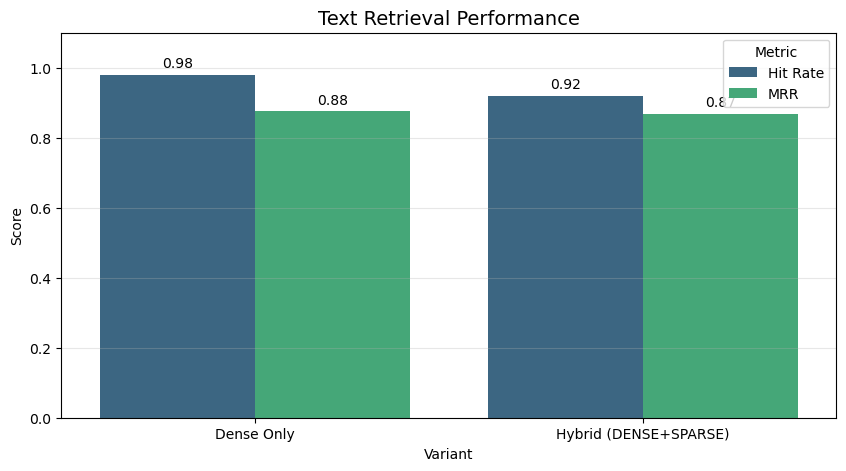

In [6]:
plot_metrics(df_text_res, "Text Retrieval Performance")

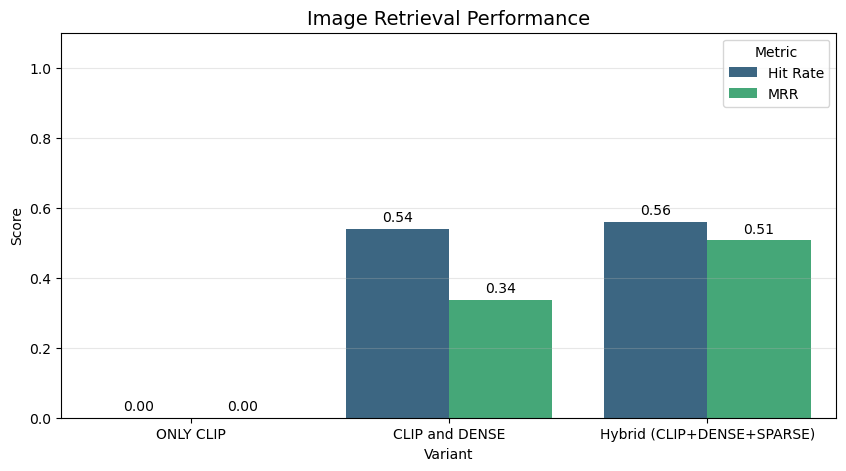

In [7]:
plot_metrics(df_image_res, "Image Retrieval Performance")